<a href="https://colab.research.google.com/github/iro9ik/humanlizeAI/blob/main/Humanize_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HumanizeAI v7 — Ateeqq/Text-Rewriter-Paraphraser
**Model:** T5-base fine-tuned on 430k paraphrase examples
**No fine-tuning needed** — works out of the box

Run order: Cell 1 → Install | Cell 2 → Load | Cell 3 → Test + Graphs | Cell 4 → Model Info | Cell 5 → API

In [ ]:
# Cell 1 - Install
!pip install -q transformers torch fastapi uvicorn nest_asyncio nltk
!pip install pyngrok==6.1.0 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 698.7/698.7 kB 16.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# Cell 2 - Load model
import torch, nltk
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

device     = 'cuda' if torch.cuda.is_available() else 'cpu'
model_name = 'Ateeqq/Text-Rewriter-Paraphraser'

print(f'Device: {device}')
print('Loading Text-Rewriter-Paraphraser (T5-base, 223M params)...')
tok   = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
model.eval()
print(f'Loaded! Free GPU: {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB')

def humanize_sentence(text, num_beams=8, num_sequences=4):
    input_ids = tok(
        f'paraphraser: {text}',
        return_tensors='pt', padding='longest',
        truncation=True, max_length=128
    ).input_ids.to(device)
    with torch.no_grad():
        outputs = model.generate(
            input_ids,
            num_beams=num_beams,
            num_beam_groups=num_sequences,
            num_return_sequences=num_sequences,
            repetition_penalty=10.0,
            diversity_penalty=3.0,
            no_repeat_ngram_size=2,
            max_length=128,
            early_stopping=True,
            trust_remote_code=True
        )
    candidates = tok.batch_decode(outputs, skip_special_tokens=True)
    inp_words = set(text.lower().split())
    best, best_overlap = candidates[0], 1.0
    for c in candidates:
        c_words = set(c.lower().split())
        overlap = len(inp_words & c_words) / max(len(c_words), 1)
        if overlap < best_overlap and len(c.split()) > 3:
            best, best_overlap = c, overlap
    return best

def humanize(text, num_beams=8):
    sentences   = sent_tokenize(text)
    transformed = [humanize_sentence(s, num_beams) for s in sentences]
    return ' '.join(transformed)

sample = 'The system autonomously synthesizes context-aware linguistic patterns to generate semantically coherent textual output.'
print('\nTest:')
print('Input :', sample)
print('Output:', humanize(sample))

Device: cuda
Loading Text-Rewriter-Paraphraser (T5-base, 223M params)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

Loaded! Free GPU: 13.54 GB

Test:
Input : The system autonomously synthesizes context-aware linguistic patterns to generate semantically coherent textual output.


generate.py: 0.00B [00:00, ?B/s]

beam_search.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/transformers-community/group-beam-search:
- custom_generate/beam_search.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/transformers-community/group-beam-search:
- custom_generate/generate.py
- beam_search.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
Passing `generation_config` together with generation-related arguments=({'repetition_penalty', 'no_repeat_ngram_size', 'num_beam_groups', 'diversity_penalty', 'early_stopping', 'max_length', 'num_return_sequences', 'num_beams'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but 

Output: In order to generate semantically coherent textual output, the system automatically synthesizes context-aware linguistic patterns.


[BORDERLINE] Overlap:67% | Diversity:33%
  IN : The system autonomously synthesizes context-aware linguistic patterns to generat...
  OUT: In order to generate semantically coherent textual output, the system automatica...

[GOOD] Overlap:36% | Diversity:64%
  IN : Artificial intelligence algorithms facilitate the optimization of complex comput...
  OUT: Complex computational processes are optimized by algorithms such as artificial i...

[BORDERLINE] Overlap:60% | Diversity:40%
  IN : The utilization of machine learning methodologies enables advanced predictive an...
  OUT: Using machine learning methodologies allows for better predictive analytical cap...

[GOOD] Overlap:50% | Diversity:50%
  IN : Neural networks process vast quantities of data to identify underlying statistic...
  OUT: Many large amounts of data are processed by neural networks to determine the und...

[GOOD] Overlap:45% | Diversity:55%
  IN : The implementation of natural language processing techniques allows for au

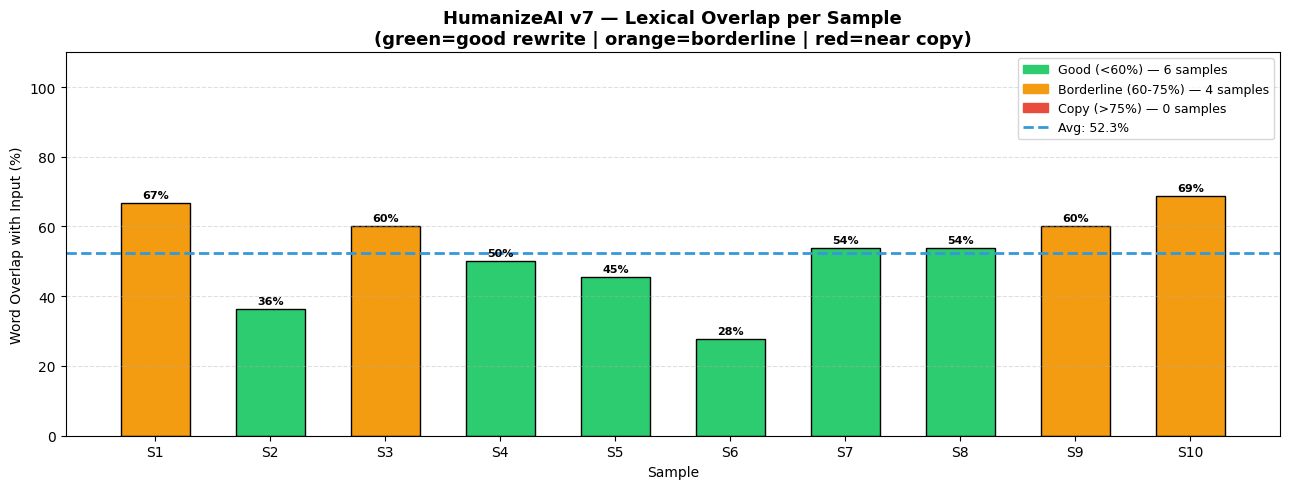

Saved: v7_overlap.png


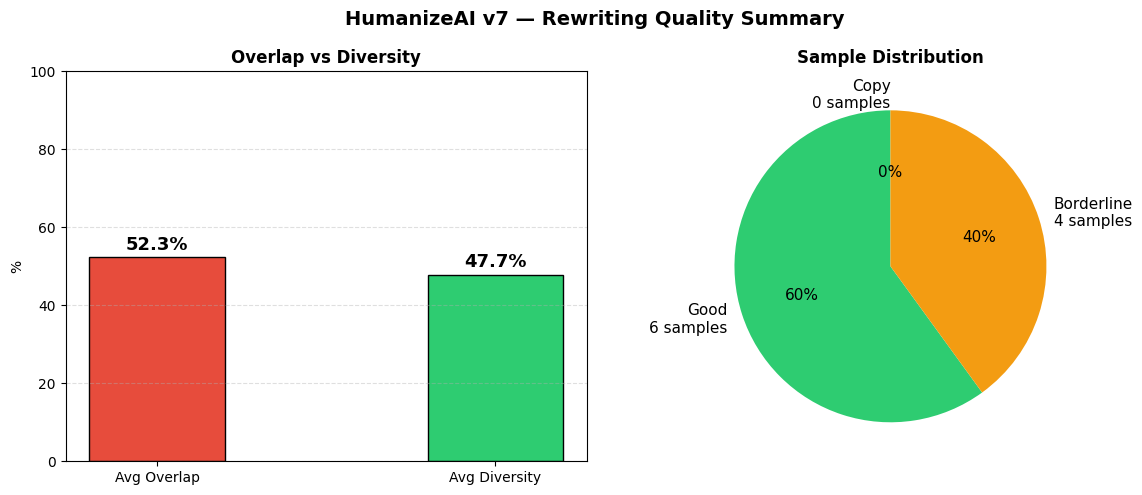

Saved: v7_summary.png

Full paragraph test | Overlap: 68% | Diversity: 32%
INPUT    : Artificial intelligence systems are designed to analyze large volumes of data and provide recommendations based on complex algorithms. These systems operate continuously to optimize processes in various domains, including healthcare, finance, and transportation. By leveraging predictive models and automated decision-making, AI applications can enhance efficiency and accuracy.
HUMANIZED: Artificial intelligence systems are designed to analyze large volumes of data and provide recommendations based on algorithms that have complex implications. In many fields, such as healthcare, finance and transportation, these systems continuously optimize processes. Artificial intelligence applications can improve efficiency and accuracy by leveraging predictive models and automated decision-making.


In [ ]:
# Cell 3 - Quality check + graphs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

test_sentences = [
    'The system autonomously synthesizes context-aware linguistic patterns to generate semantically coherent textual output.',
    'Artificial intelligence algorithms facilitate the optimization of complex computational processes.',
    'The utilization of machine learning methodologies enables advanced predictive analytical capabilities.',
    'Neural networks process vast quantities of data to identify underlying statistical regularities.',
    'The implementation of natural language processing techniques allows for automated text classification.',
    'Predictive models analyze behavioral patterns, optimizing decision-making across various domains.',
    'By leveraging deep learning architectures, systems can extract high-level feature representations.',
    'The convergence of computational intelligence and data analytics enables sophisticated pattern recognition.',
    'Automated systems continuously curate personalized environments based on user behavioral data.',
    'The distinction between organic thought and programmed inference diminishes in modern AI systems.',
]

def word_overlap(inp, out):
    i = set(inp.lower().split())
    o = set(out.lower().split())
    return len(i & o) / max(len(o), 1) * 100

def lex_diversity(inp, out):
    i = set(inp.lower().split())
    o = set(out.lower().split())
    return len(o - i) / max(len(o), 1) * 100

print('=' * 70)
overlaps, diversities, preds = [], [], []
for sent in test_sentences:
    out = humanize_sentence(sent)
    ov  = word_overlap(sent, out)
    div = lex_diversity(sent, out)
    overlaps.append(ov)
    diversities.append(div)
    preds.append(out)
    status = 'GOOD' if ov < 60 else 'BORDERLINE' if ov < 75 else 'COPY'
    print(f'[{status}] Overlap:{ov:.0f}% | Diversity:{div:.0f}%')
    print(f'  IN : {sent[:80]}...' if len(sent)>80 else f'  IN : {sent}')
    print(f'  OUT: {out[:80]}...' if len(out)>80 else f'  OUT: {out}')
    print()

avg_ov  = sum(overlaps)    / len(overlaps)
avg_div = sum(diversities) / len(diversities)
good    = sum(1 for v in overlaps if v < 60)
border  = sum(1 for v in overlaps if 60 <= v < 75)
copy    = sum(1 for v in overlaps if v >= 75)
print(f'Avg overlap: {avg_ov:.1f}% | Avg diversity: {avg_div:.1f}%')
print(f'GOOD: {good} | BORDERLINE: {border} | COPY: {copy}')

# Graph 1: Overlap per sample
fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#2ecc71' if v < 60 else '#e74c3c' if v > 75 else '#f39c12' for v in overlaps]
bars   = ax.bar([f'S{i+1}' for i in range(len(overlaps))], overlaps, color=colors, edgecolor='black', width=0.6)
ax.axhline(y=avg_ov, color='#3498db', linestyle='--', lw=2, label=f'Avg overlap: {avg_ov:.1f}%')
for bar, val in zip(bars, overlaps):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5, f'{val:.0f}%', ha='center', fontsize=8, fontweight='bold')
good_p   = mpatches.Patch(color='#2ecc71', label=f'Good (<60%) — {good} samples')
border_p = mpatches.Patch(color='#f39c12', label=f'Borderline (60-75%) — {border} samples')
copy_p   = mpatches.Patch(color='#e74c3c', label=f'Copy (>75%) — {copy} samples')
ax.legend(handles=[good_p, border_p, copy_p, plt.Line2D([0],[0], color='#3498db', linestyle='--', lw=2, label=f'Avg: {avg_ov:.1f}%')], fontsize=9)
ax.set_title('HumanizeAI v7 — Lexical Overlap per Sample\n(green=good rewrite | orange=borderline | red=near copy)', fontsize=13, fontweight='bold')
ax.set_xlabel('Sample')
ax.set_ylabel('Word Overlap with Input (%)')
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('v7_overlap.png', dpi=150)
plt.show()
print('Saved: v7_overlap.png')

# Graph 2: Diversity vs overlap summary
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle('HumanizeAI v7 — Rewriting Quality Summary', fontsize=14, fontweight='bold')
axes2[0].bar(['Avg Overlap', 'Avg Diversity'], [avg_ov, avg_div],
             color=['#e74c3c', '#2ecc71'], width=0.4, edgecolor='black')
axes2[0].set_ylim(0, 100)
axes2[0].set_ylabel('%')
axes2[0].set_title('Overlap vs Diversity', fontweight='bold')
for i, (label, val) in enumerate([('Overlap', avg_ov), ('Diversity', avg_div)]):
    axes2[0].text(i, val + 2, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)
axes2[0].grid(axis='y', linestyle='--', alpha=0.4)

axes2[1].pie([good, border, copy],
             labels=[f'Good\n{good} samples', f'Borderline\n{border} samples', f'Copy\n{copy} samples'],
             colors=['#2ecc71', '#f39c12', '#e74c3c'],
             autopct='%1.0f%%', startangle=90,
             textprops={'fontsize': 11})
axes2[1].set_title('Sample Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('v7_summary.png', dpi=150)
plt.show()
print('Saved: v7_summary.png')

# Full paragraph test
para = 'Artificial intelligence systems are designed to analyze large volumes of data and provide recommendations based on complex algorithms. These systems operate continuously to optimize processes in various domains, including healthcare, finance, and transportation. By leveraging predictive models and automated decision-making, AI applications can enhance efficiency and accuracy.'
out_para = humanize(para)
para_ov  = word_overlap(para, out_para)
para_div = lex_diversity(para, out_para)
print('\n' + '=' * 70)
print(f'Full paragraph test | Overlap: {para_ov:.0f}% | Diversity: {para_div:.0f}%')
print(f'INPUT    : {para}')
print(f'HUMANIZED: {out_para}')

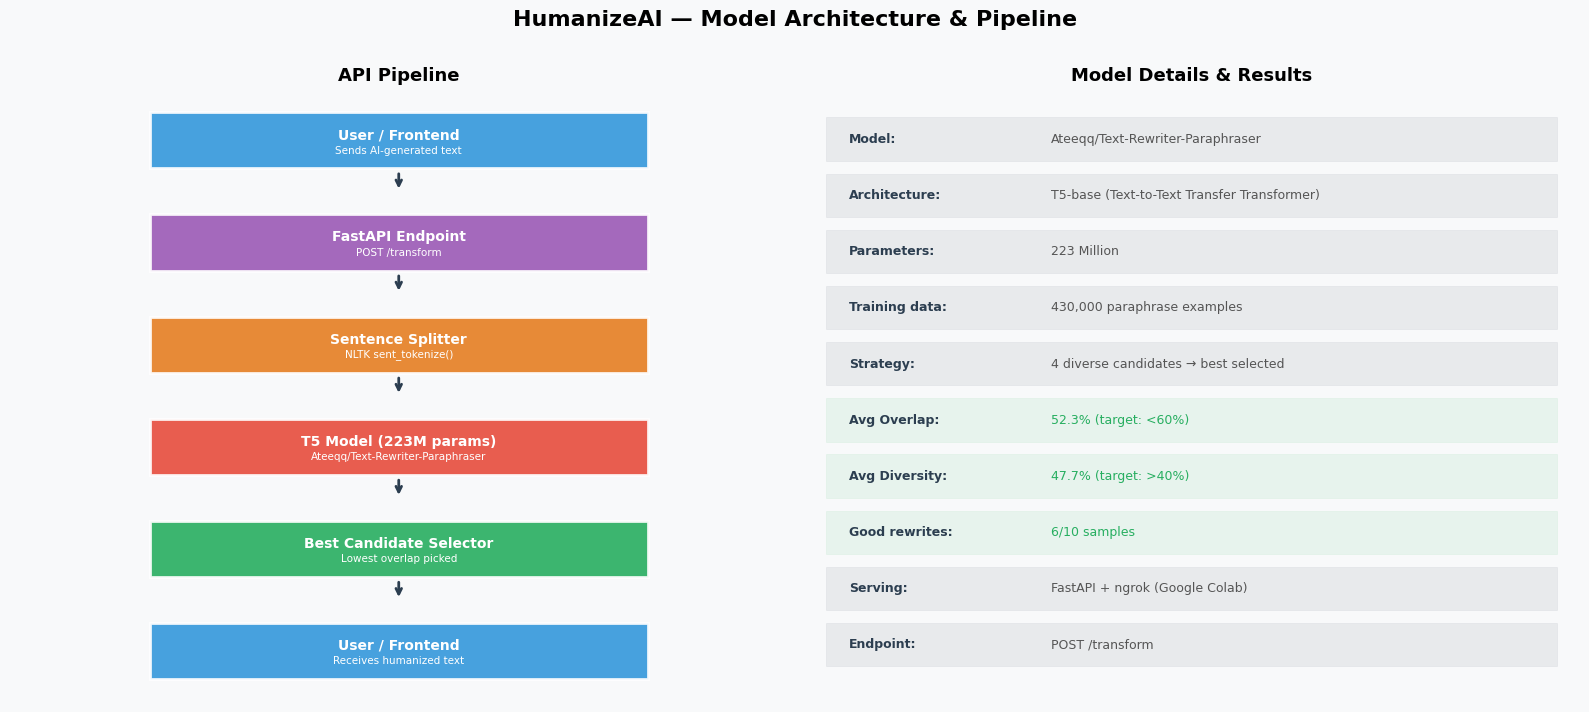

Saved: v7_architecture.png
Download all 3 PNGs from the left sidebar in Colab


In [ ]:
# Cell 4 - Model architecture & pipeline visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#f8f9fa')
fig.suptitle('HumanizeAI — Model Architecture & Pipeline', fontsize=16, fontweight='bold', y=1.01)

# ── Left: Pipeline flow ────────────────────────────────────────────────────
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 12)
ax1.axis('off')
ax1.set_title('API Pipeline', fontsize=13, fontweight='bold')

steps = [
    (5, 11,   '#3498db', 'User / Frontend',         'Sends AI-generated text'),
    (5,  9,   '#9b59b6', 'FastAPI Endpoint',         'POST /transform'),
    (5,  7,   '#e67e22', 'Sentence Splitter',        'NLTK sent_tokenize()'),
    (5,  5,   '#e74c3c', 'T5 Model (223M params)',   'Ateeqq/Text-Rewriter-Paraphraser'),
    (5,  3,   '#27ae60', 'Best Candidate Selector',  'Lowest overlap picked'),
    (5,  1,   '#3498db', 'User / Frontend',          'Receives humanized text'),
]
for x, y, color, title, sub in steps:
    ax1.add_patch(plt.Rectangle((x-3.2, y-0.55), 6.4, 1.1,
                                facecolor=color, edgecolor='white', linewidth=2, alpha=0.9, zorder=2))
    ax1.text(x, y+0.1, title, ha='center', va='center', color='white',
             fontsize=10, fontweight='bold', zorder=3)
    ax1.text(x, y-0.2, sub, ha='center', va='center', color='white',
             fontsize=7.5, zorder=3)

for y_start in [10.4, 8.4, 6.4, 4.4, 2.4]:
    ax1.annotate('', xy=(5, y_start-0.4), xytext=(5, y_start),
                 arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2))

# ── Right: Model stats ─────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 12)
ax2.axis('off')
ax2.set_title('Model Details & Results', fontsize=13, fontweight='bold')

stats = [
    ('Model',            'Ateeqq/Text-Rewriter-Paraphraser'),
    ('Architecture',     'T5-base (Text-to-Text Transfer Transformer)'),
    ('Parameters',       '223 Million'),
    ('Training data',    '430,000 paraphrase examples'),
    ('Strategy',         '4 diverse candidates → best selected'),
    ('Avg Overlap',      f'{avg_ov:.1f}% (target: <60%)'),
    ('Avg Diversity',    f'{avg_div:.1f}% (target: >40%)'),
    ('Good rewrites',    f'{good}/10 samples'),
    ('Serving',          'FastAPI + ngrok (Google Colab)'),
    ('Endpoint',         'POST /transform'),
]
colors_stats = ['#2c3e50', '#2c3e50', '#2c3e50', '#2c3e50', '#2c3e50',
                '#27ae60', '#27ae60', '#27ae60', '#2c3e50', '#2c3e50']
for idx, ((key, val), c) in enumerate(zip(stats, colors_stats)):
    y = 11 - idx * 1.1
    ax2.add_patch(plt.Rectangle((0.3, y-0.4), 9.4, 0.85,
                                facecolor=c, alpha=0.08, edgecolor=c, linewidth=0.5))
    ax2.text(0.6, y+0.02, f'{key}:', fontsize=9, fontweight='bold', color='#2c3e50', va='center')
    ax2.text(3.2, y+0.02, val, fontsize=9, color=c if c != '#2c3e50' else '#555555', va='center')

plt.tight_layout()
plt.savefig('v7_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: v7_architecture.png')
print('Download all 3 PNGs from the left sidebar in Colab')

In [ ]:
# Cell 5 - Start API
NGROK_TOKEN = '3BcpqtaaUEOYAudbEFE0eYqpuat_3hL9nPjY4QvQqDHGEvGMT'

import nest_asyncio, uvicorn, threading
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from pyngrok import ngrok, conf
from nltk.tokenize import sent_tokenize

nest_asyncio.apply()

# Fix ngrok binary issue
conf.get_default().ngrok_path = '/root/.local/bin/ngrok'

app = FastAPI(title='HumanizeAI API v7')
app.add_middleware(CORSMiddleware, allow_origins=['*'], allow_methods=['*'], allow_headers=['*'])

class Req(BaseModel):
    text: str
    num_beams: int = 8

class Res(BaseModel):
    original: str
    transformed: str
    sentences_processed: int
    model: str

@app.get('/')
def root(): return {'status': 'running', 'model': model_name, 'project': 'HumanizeAI v7'}

@app.get('/health')
def health(): return {'status': 'ok', 'device': device}

@app.post('/transform', response_model=Res)
def transform(req: Req):
    if not req.text.strip():
        raise HTTPException(400, 'Text cannot be empty')
    if len(req.text) > 5000:
        raise HTTPException(400, 'Text too long, max 5000 chars')
    sentences   = sent_tokenize(req.text)
    transformed = [humanize_sentence(s, req.num_beams) for s in sentences]
    return Res(
        original=req.text,
        transformed=' '.join(transformed),
        sentences_processed=len(sentences),
        model=model_name
    )

config = uvicorn.Config(app, host='0.0.0.0', port=8000, log_level='error')
server = uvicorn.Server(config)
threading.Thread(target=server.run, daemon=True).start()

ngrok.set_auth_token(NGROK_TOKEN)
url = ngrok.connect(8000)
print('=' * 50)
print(f'  HumanizeAI v7 API is LIVE')
print(f'  API URL : {url}')
print(f'  Swagger : {url}/docs')
print('=' * 50)

ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use


  HumanizeAI v7 API is LIVE
  API URL : NgrokTunnel: "https://todd-eradicable-carlotta.ngrok-free.dev" -> "http://localhost:8000"
  Swagger : NgrokTunnel: "https://todd-eradicable-carlotta.ngrok-free.dev" -> "http://localhost:8000"/docs
